# Research Companion 02
## Same Visible Size, Different Dynamical Structure?

**Roberto Casado Vara, BISITE Research Group, University of Salamanca**

This notebook compares two Variational Quantum Circuit designs with identical visible architectural counts, but different generator families.

The local-rotation contrast deliberately follows **Research Companion 01**:

- **VQC A:** \(R_y\) and \(R_z\) local rotations
- **VQC B:** \(R_y\) and \(R_y\) local rotations

For this structural experiment, the fixed CZ entanglers used previously are replaced by **parametrized \(R_{ZZ}\) interactions**. This makes the interaction Hamiltonians explicit generators and allows the Dynamical Lie Algebra (DLA) question to be formulated cleanly.

**Can two VQCs with the same number of qubits, trainable parameters, circuit depth and quantum operations generate fundamentally different Lie closures?**

This is a generator-level structural diagnostic. It does **not** claim that a finite-depth circuit explores the entire associated dynamical group, nor that a larger DLA automatically implies better trainability or predictive performance.


### Setup

Python 3.10 or newer is recommended. The notebook targets **Qiskit 2.5.1**.

The experiment is small: three qubits and Pauli-string generators. The complete Lie closure can therefore be computed exactly on a standard laptop.


In [1]:
%pip install -q "qiskit==2.5.1" matplotlib pandas pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.2 MB/s eta 0:00:00


In [2]:
from dataclasses import dataclass
from collections import Counter
from typing import Iterable
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7.5, 4.5), "figure.dpi": 120})

print("Qiskit:", qiskit.__version__)


Qiskit: 2.5.1


## 1. Controlled structural setting

The comparison is deliberately minimal.

Both circuits use:

- 3 qubits,
- 2 layers,
- the same ring connectivity,
- one parametrized \(R_{ZZ}\) interaction on every ring edge,
- two local parametrized rotations per qubit and layer.

The only difference is the axis of the **second local rotation**:

- **VQC A:** \(R_y\) followed by \(R_z\)
- **VQC B:** \(R_y\) followed by \(R_y\)

The circuits therefore have the same visible size, while their **unique Hamiltonian generator families** need not be the same.


In [3]:
N_QUBITS = 3
N_LAYERS = 2

RING_EDGES = tuple(
    (qubit, (qubit + 1) % N_QUBITS)
    for qubit in range(N_QUBITS)
)

print("Qubits:", N_QUBITS)
print("Layers:", N_LAYERS)
print("Ring edges:", RING_EDGES)


Qubits: 3
Layers: 2
Ring edges: ((0, 1), (1, 2), (2, 0))


## 2. Two circuits with identical architectural counts


In [4]:
@dataclass(frozen=True)
class StructuralVQC:
    name: str
    circuit: QuantumCircuit
    theta_params: tuple[Parameter, ...]
    generator_labels: tuple[str, ...]

    @property
    def n_parameters(self) -> int:
        return len(self.theta_params)


def pauli_label_single(axis: str, qubit: int) -> str:
    # Qiskit Pauli-label convention: q_(n-1) ... q_0
    if axis not in {"X", "Y", "Z"}:
        raise ValueError(f"Invalid Pauli axis: {axis}")

    label = ["I"] * N_QUBITS
    label[N_QUBITS - 1 - qubit] = axis
    return "".join(label)


def pauli_label_pair(
    axis_a: str,
    qubit_a: int,
    axis_b: str,
    qubit_b: int,
) -> str:
    if axis_a not in {"X", "Y", "Z"}:
        raise ValueError(f"Invalid Pauli axis: {axis_a}")
    if axis_b not in {"X", "Y", "Z"}:
        raise ValueError(f"Invalid Pauli axis: {axis_b}")

    label = ["I"] * N_QUBITS
    label[N_QUBITS - 1 - qubit_a] = axis_a
    label[N_QUBITS - 1 - qubit_b] = axis_b
    return "".join(label)


def unique_generator_family(second_pauli: str) -> tuple[str, ...]:
    generators = []

    # First local rotation block: RY -> Pauli Y generator
    generators.extend(
        pauli_label_single("Y", qubit)
        for qubit in range(N_QUBITS)
    )

    # Shared entangling family: RZZ -> Pauli ZZ generator
    generators.extend(
        pauli_label_pair("Z", left, "Z", right)
        for left, right in RING_EDGES
    )

    # Second local rotation block
    generators.extend(
        pauli_label_single(second_pauli, qubit)
        for qubit in range(N_QUBITS)
    )

    # Repeated layers do not create new Hamiltonian types.
    unique = tuple(sorted(set(generators)))

    # Defensive checks: every generator must be a valid n-qubit Pauli string.
    assert all(len(label) == N_QUBITS for label in unique)
    assert all(set(label) <= {"I", "X", "Y", "Z"} for label in unique)

    return unique


def build_structural_vqc(
    name: str,
    second_gate: str,
    second_pauli: str,
) -> StructuralVQC:
    parameters_per_layer = 3 * N_QUBITS
    theta = ParameterVector(
        f"theta_{name}",
        N_LAYERS * parameters_per_layer,
    )

    circuit = QuantumCircuit(N_QUBITS, name=name)
    cursor = 0

    for _ in range(N_LAYERS):
        # Local RY block
        for qubit in range(N_QUBITS):
            circuit.ry(theta[cursor], qubit)
            cursor += 1

        # Parametrized ZZ ring
        for left, right in RING_EDGES:
            circuit.rzz(theta[cursor], left, right)
            cursor += 1

        # Second local block
        for qubit in range(N_QUBITS):
            getattr(circuit, second_gate)(
                theta[cursor],
                qubit,
            )
            cursor += 1

    return StructuralVQC(
        name=name,
        circuit=circuit,
        theta_params=tuple(theta),
        generator_labels=unique_generator_family(second_pauli),
    )


model_a = build_structural_vqc(
    "A_RY_RZ",
    second_gate="rz",
    second_pauli="Z",
)

model_b = build_structural_vqc(
    "B_RY_RY",
    second_gate="ry",
    second_pauli="Y",
)

models = (model_a, model_b)


In [5]:
architecture = pd.DataFrame(
    {
        model.name: {
            "Qubits": model.circuit.num_qubits,
            "Trainable parameters": model.n_parameters,
            "Circuit depth": model.circuit.depth(),
            "Circuit size": model.circuit.size(),
        }
        for model in models
    }
).T

display(architecture)

assert architecture.nunique().eq(1).all(), (
    "The two circuits must have identical visible architectural counts."
)


,Qubits,Trainable parameters,Circuit depth,Circuit size
A_RY_RZ,3,18,10,18
B_RY_RY,3,18,10,18


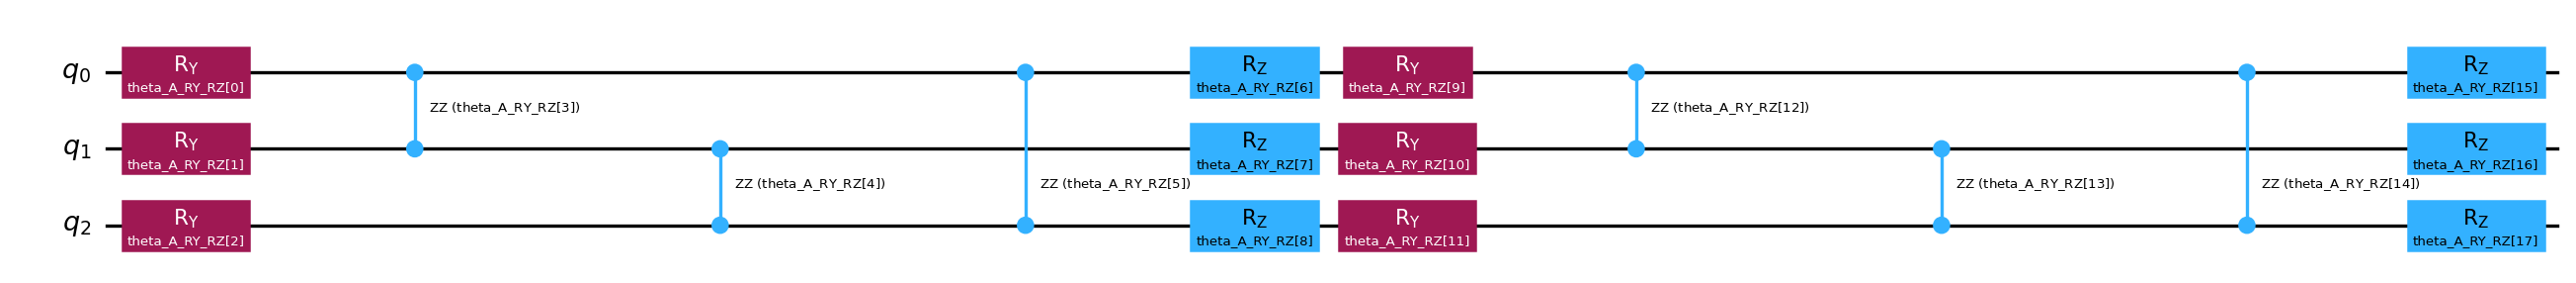

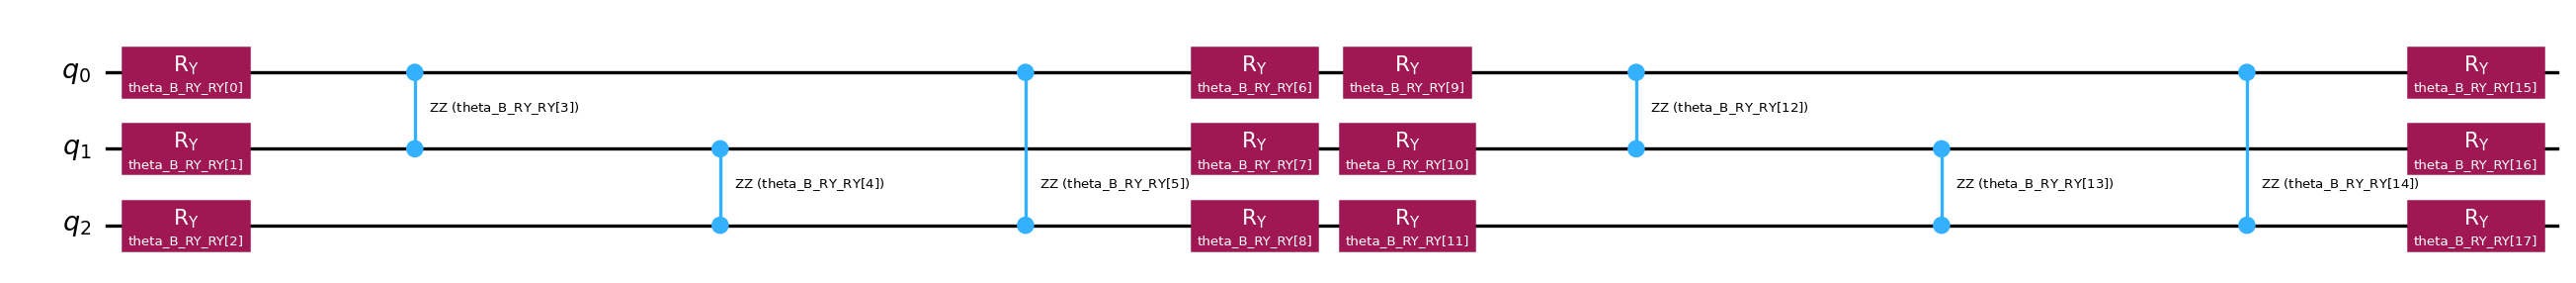

In [6]:
display(model_a.circuit.draw("mpl", style="iqp", fold=-1))
display(model_b.circuit.draw("mpl", style="iqp", fold=-1))


## 3. From gates to Hamiltonian generators

For Pauli rotations,

\[
R_P(\theta)=e^{-i\theta P/2},
\]

so the relevant generator direction is the Pauli operator \(P\), up to an irrelevant scalar factor.

The two circuits therefore start from the following unique generator families:

\[
\mathcal{G}_A=
\{Y_i,\; Z_i,\; Z_iZ_j\},
\]

\[
\mathcal{G}_B=
\{Y_i,\; Z_iZ_j\},
\]

with \(i\) running over the three qubits and \((i,j)\) over the ring edges.

The repeated appearance of a generator in several layers changes the finite-depth parametrization, but it does not add a new direction to the initial Lie-generating set.


In [7]:
generator_table = pd.DataFrame(
    {
        model.name: pd.Series(model.generator_labels)
        for model in models
    }
)

display(generator_table)

print(
    model_a.name,
    "unique initial generators:",
    len(model_a.generator_labels),
)
print(
    model_b.name,
    "unique initial generators:",
    len(model_b.generator_labels),
)


,A_RY_RZ,B_RY_RY
0,IIY,IIY
1,IIZ,IYI
2,IYI,IZZ
3,IZI,YII
4,IZZ,ZIZ
5,YII,ZZI
6,ZII,NaN
7,ZIZ,NaN
8,ZZI,NaN


A_RY_RZ unique initial generators: 9
B_RY_RY unique initial generators: 6


## 4. Lie closure under commutators

For Pauli strings, two useful facts make the closure particularly transparent:

1. commuting Pauli strings have zero commutator;
2. the commutator of two anticommuting Pauli strings is proportional to another Pauli string.

Therefore, for the purpose of computing the **linear span** of the DLA, global scalar factors and phases can be ignored.

Starting from the initial generators, we repeatedly add every new Pauli direction produced by non-zero commutators until no new direction appears.


In [8]:
def anticommute(left: str, right: str) -> bool:
    disagreements = 0

    for a, b in zip(left, right):
        if (
            a != "I"
            and b != "I"
            and a != b
        ):
            disagreements += 1

    return disagreements % 2 == 1


def pauli_product_ignoring_phase(
    left: str,
    right: str,
) -> str:
    product = []

    for a, b in zip(left, right):
        if a == "I":
            product.append(b)
        elif b == "I":
            product.append(a)
        elif a == b:
            product.append("I")
        else:
            product.append(
                ({"X", "Y", "Z"} - {a, b}).pop()
            )

    return "".join(product)


def lie_closure(
    initial_generators: Iterable[str],
) -> tuple[set[str], list[int], list[set[str]]]:
    closure = set(initial_generators)
    cumulative_dimensions = [len(closure)]
    new_directions_by_round = [set(closure)]

    while True:
        new_directions = set()
        current = sorted(closure)

        for left_index in range(len(current)):
            for right_index in range(
                left_index + 1,
                len(current),
            ):
                left = current[left_index]
                right = current[right_index]

                if not anticommute(left, right):
                    continue

                candidate = pauli_product_ignoring_phase(
                    left,
                    right,
                )

                if (
                    candidate != "I" * N_QUBITS
                    and candidate not in closure
                ):
                    new_directions.add(candidate)

        if not new_directions:
            break

        closure |= new_directions
        cumulative_dimensions.append(len(closure))
        new_directions_by_round.append(new_directions)

    return (
        closure,
        cumulative_dimensions,
        new_directions_by_round,
    )


closure_a, growth_a, rounds_a = lie_closure(
    model_a.generator_labels
)
closure_b, growth_b, rounds_b = lie_closure(
    model_b.generator_labels
)

print(model_a.name, "DLA dimension:", len(closure_a))
print(model_b.name, "DLA dimension:", len(closure_b))


A_RY_RZ DLA dimension: 63
B_RY_RY DLA dimension: 30


Because distinct non-identity Pauli strings are linearly independent, the number of strings in the final closure is exactly the dimension of the generated real Lie algebra in this Pauli basis.

For three qubits,

\[
\dim\mathfrak{su}(2^3)=4^3-1=63.
\]

The value 63 therefore provides a useful reference for the full traceless operator algebra.


In [9]:
FULL_SU_DIMENSION = 4**N_QUBITS - 1

assert len(closure_a) == 63
assert len(closure_b) == 30
assert closure_b.issubset(closure_a)

structural_summary = pd.DataFrame(
    {
        model_a.name: {
            "Visible trainable parameters": model_a.n_parameters,
            "Unique initial generators": len(model_a.generator_labels),
            "DLA dimension": len(closure_a),
            "Fraction of su(8)": len(closure_a) / FULL_SU_DIMENSION,
        },
        model_b.name: {
            "Visible trainable parameters": model_b.n_parameters,
            "Unique initial generators": len(model_b.generator_labels),
            "DLA dimension": len(closure_b),
            "Fraction of su(8)": len(closure_b) / FULL_SU_DIMENSION,
        },
    }
).T

display(
    structural_summary.style.format(
        {"Fraction of su(8)": "{:.3f}"}
    )
)

print(
    "Full three-qubit traceless operator dimension:",
    FULL_SU_DIMENSION,
)


,Visible trainable parameters,Unique initial generators,DLA dimension,Fraction of su(8)
A_RY_RZ,18.000000,9.000000,63.000000,1.000
B_RY_RY,18.000000,6.000000,30.000000,0.476


Full three-qubit traceless operator dimension: 63


## 5. How does the algebra grow?

The final dimensions are useful, but the **route to closure** is also informative.

The next plot records the cumulative number of independent Pauli directions after each commutator round.


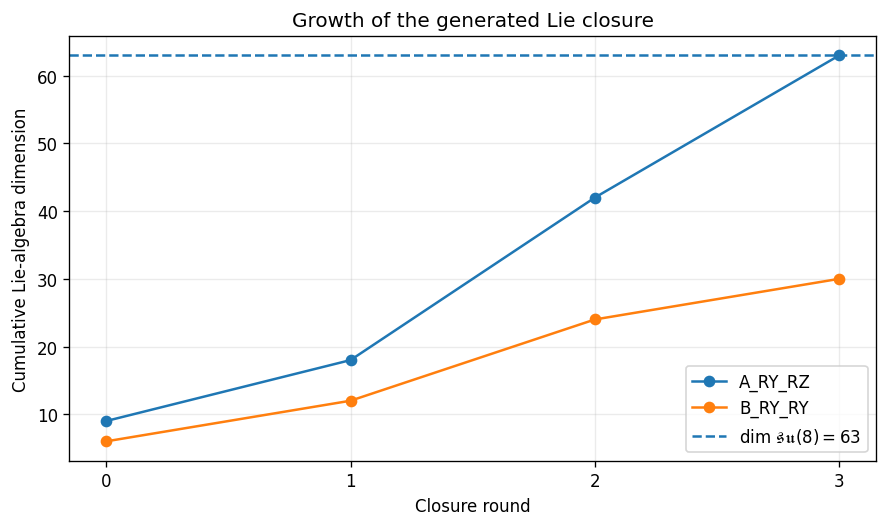

A_RY_RZ growth: [9, 18, 42, 63]
B_RY_RY growth: [6, 12, 24, 30]


In [10]:
plt.figure()

plt.plot(
    range(len(growth_a)),
    growth_a,
    marker="o",
    label=model_a.name,
)
plt.plot(
    range(len(growth_b)),
    growth_b,
    marker="o",
    label=model_b.name,
)

plt.axhline(
    FULL_SU_DIMENSION,
    linestyle="--",
    label=r"$\dim\,\mathfrak{su}(8)=63$",
)

plt.xlabel("Closure round")
plt.ylabel("Cumulative Lie-algebra dimension")
plt.title("Growth of the generated Lie closure")
plt.xticks(
    range(max(len(growth_a), len(growth_b)))
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(model_a.name, "growth:", growth_a)
print(model_b.name, "growth:", growth_b)


## 6. What kinds of Pauli directions appear?

The **Pauli weight** of a string is the number of qubits on which it acts non-trivially.

A comparison by weight gives a simple view of how much one-, two- and three-qubit operator structure appears in each closure.


,A_RY_RZ,B_RY_RY
Pauli weight,,
1,9,3
2,27,15
3,27,12


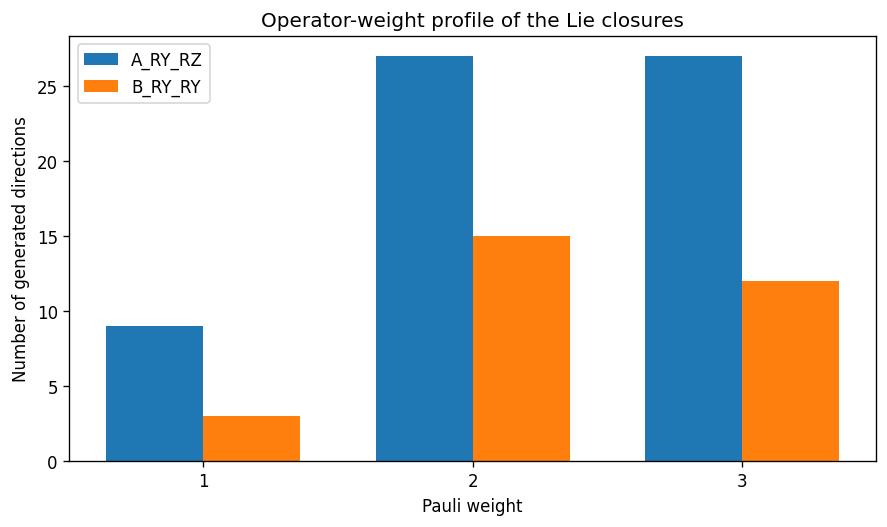

In [11]:
def pauli_weight(label: str) -> int:
    return sum(symbol != "I" for symbol in label)


def weight_profile(closure: set[str]) -> dict[int, int]:
    counts = Counter(
        pauli_weight(label)
        for label in closure
    )
    return {
        weight: counts.get(weight, 0)
        for weight in range(1, N_QUBITS + 1)
    }


profile_a = weight_profile(closure_a)
profile_b = weight_profile(closure_b)

weight_table = pd.DataFrame(
    {
        model_a.name: profile_a,
        model_b.name: profile_b,
    }
)
weight_table.index.name = "Pauli weight"

display(weight_table)

x = np.arange(1, N_QUBITS + 1)
width = 0.36

plt.figure()
plt.bar(
    x - width / 2,
    [profile_a[w] for w in x],
    width=width,
    label=model_a.name,
)
plt.bar(
    x + width / 2,
    [profile_b[w] for w in x],
    width=width,
    label=model_b.name,
)

plt.xlabel("Pauli weight")
plt.ylabel("Number of generated directions")
plt.title("Operator-weight profile of the Lie closures")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Same visible size, different generated structure

The comparison can now be summarized without using any training data, loss function or optimizer.


In [12]:
comparison = pd.DataFrame(
    {
        "Quantity": [
            "Qubits",
            "Trainable parameters",
            "Circuit depth",
            "Circuit size",
            "Unique initial generators",
            "DLA dimension",
            "One-body directions",
            "Two-body directions",
            "Three-body directions",
        ],
        model_a.name: [
            model_a.circuit.num_qubits,
            model_a.n_parameters,
            model_a.circuit.depth(),
            model_a.circuit.size(),
            len(model_a.generator_labels),
            len(closure_a),
            profile_a[1],
            profile_a[2],
            profile_a[3],
        ],
        model_b.name: [
            model_b.circuit.num_qubits,
            model_b.n_parameters,
            model_b.circuit.depth(),
            model_b.circuit.size(),
            len(model_b.generator_labels),
            len(closure_b),
            profile_b[1],
            profile_b[2],
            profile_b[3],
        ],
    }
)

display(comparison)

print(
    "Shared Lie directions:",
    len(closure_a & closure_b),
)
print(
    "Directions present only in A:",
    len(closure_a - closure_b),
)
print(
    "Directions present only in B:",
    len(closure_b - closure_a),
)


,Quantity,A_RY_RZ,B_RY_RY
0,Qubits,3,3
1,Trainable parameters,18,18
2,Circuit depth,10,10
3,Circuit size,18,18
4,Unique initial generators,9,6
5,DLA dimension,63,30
6,One-body directions,9,3
7,Two-body directions,27,15
8,Three-body directions,27,12


Shared Lie directions: 30
Directions present only in A: 33
Directions present only in B: 0


## 8. Why does VQC B stop at dimension 30?

The difference between dimensions 63 and 30 is not just a numerical accident.  
The generator family of **VQC B** preserves a global Pauli symmetry,

\[
S = Y\otimes Y\otimes Y.
\]

Every local \(Y_i\) generator commutes with \(S\). Each \(Z_iZ_j\) interaction also commutes with \(S\), because it produces two local anticommutations with the \(Y\) factors and the two signs cancel.

Consequently, every nested commutator generated from the VQC B family must also commute with \(S\). Its DLA is therefore confined to the commutant of this symmetry.


In [13]:
GLOBAL_SYMMETRY = "Y" * N_QUBITS

def commutes(left: str, right: str) -> bool:
    return not anticommute(left, right)

b_commutes_with_symmetry = all(
    commutes(generator, GLOBAL_SYMMETRY)
    for generator in model_b.generator_labels
)

a_symmetry_breaking_generators = [
    generator
    for generator in model_a.generator_labels
    if not commutes(generator, GLOBAL_SYMMETRY)
]

print("Global symmetry:", GLOBAL_SYMMETRY)
print(
    "All VQC B initial generators commute with the symmetry:",
    b_commutes_with_symmetry,
)
print(
    "VQC A generators that break the symmetry:",
    a_symmetry_breaking_generators,
)

assert b_commutes_with_symmetry
assert set(a_symmetry_breaking_generators) == {"IIZ", "IZI", "ZII"}


Global symmetry: YYY
All VQC B initial generators commute with the symmetry: True
VQC A generators that break the symmetry: ['IIZ', 'IZI', 'ZII']


The crucial change in **VQC A** is therefore the addition of the local \(Z_i\) generators. These do **not** commute with \(Y\otimes Y\otimes Y\). They break the symmetry that constrains VQC B and allow the Lie closure to connect dynamical directions that were previously separated.


In [14]:
from itertools import product

all_pauli_strings = [
    "".join(symbols)
    for symbols in product("IXYZ", repeat=N_QUBITS)
]

nonidentity_commutant = {
    label
    for label in all_pauli_strings
    if label != "I" * N_QUBITS
    and commutes(label, GLOBAL_SYMMETRY)
}

print(
    "Non-identity Pauli directions commuting with the symmetry:",
    len(nonidentity_commutant),
)
print(
    "Is the symmetry itself generated by VQC B?",
    GLOBAL_SYMMETRY in closure_b,
)
print(
    "Does VQC B generate every other traceless Pauli direction "
    "that commutes with the symmetry?",
    closure_b == nonidentity_commutant - {GLOBAL_SYMMETRY},
)

assert len(nonidentity_commutant) == 31
assert GLOBAL_SYMMETRY not in closure_b
assert closure_b == nonidentity_commutant - {GLOBAL_SYMMETRY}


Non-identity Pauli directions commuting with the symmetry: 31
Is the symmetry itself generated by VQC B? False
Does VQC B generate every other traceless Pauli direction that commutes with the symmetry? True


There are **31** non-identity Pauli directions commuting with \(S\). VQC B generates exactly 30 of them: all except the symmetry operator \(S\) itself.

This has a clean algebraic interpretation. The operator \(S\) has eigenvalues \(+1\) and \(-1\), each with multiplicity four, so the Hilbert space decomposes into two invariant sectors,

\[
\mathcal H = \mathcal H_{+}\oplus\mathcal H_{-},
\qquad
\dim\mathcal H_{+}=\dim\mathcal H_{-}=4.
\]

The traceless operators commuting with \(S\) form

\[
\mathfrak{s}\bigl(\mathfrak{u}(4)\oplus\mathfrak{u}(4)\bigr),
\]

which has dimension 31. Removing the one-dimensional direction associated with \(S\) leaves

\[
\boxed{
\mathfrak g_B \simeq
\mathfrak{su}(4)\oplus\mathfrak{su}(4)
}
\]

with dimension

\[
15+15=30.
\]

By contrast, the additional local \(Z_i\) generators in VQC A break this sector-preserving symmetry, and its closure expands to the full

\[
\boxed{
\mathfrak g_A=\mathfrak{su}(8)
}
\]

of dimension 63.


In [15]:
# Optional numerical check of the symmetry sectors.

Y = np.array(
    [
        [0.0, -1.0j],
        [1.0j, 0.0],
    ],
    dtype=complex,
)

symmetry_matrix = Y
for _ in range(N_QUBITS - 1):
    symmetry_matrix = np.kron(symmetry_matrix, Y)

eigenvalues = np.linalg.eigvalsh(symmetry_matrix)

sector_dimensions = {
    "+1 sector": int(np.sum(np.isclose(eigenvalues, 1.0))),
    "-1 sector": int(np.sum(np.isclose(eigenvalues, -1.0))),
}

display(
    pd.DataFrame.from_dict(
        sector_dimensions,
        orient="index",
        columns=["Dimension"],
    )
)

assert sector_dimensions["+1 sector"] == 4
assert sector_dimensions["-1 sector"] == 4


,Dimension
+1 sector,4
-1 sector,4
